# exploratory data analysis (EDA)

In [276]:
import pandas as pd

df = pd.read_csv("train.csv")
test_data = pd.read_csv('test.csv')

print(df.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [278]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

in this case the  mean>median : so the distubtion must be right skeweed


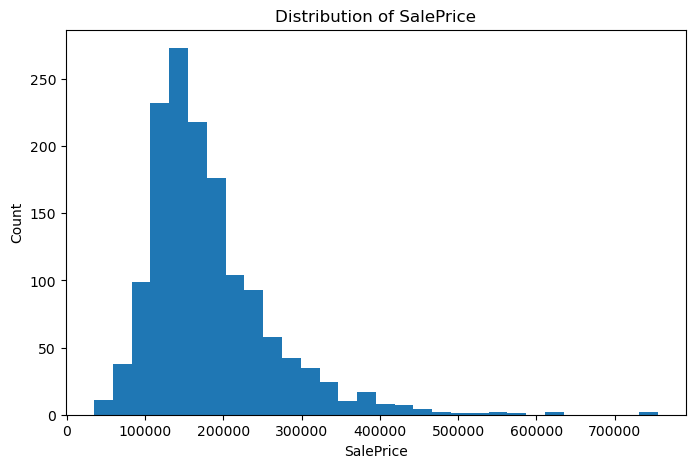

In [279]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["SalePrice"], bins=30)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")

plt.show()

In [280]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [281]:
df["PoolQC"].value_counts()
df["Alley"].value_counts()


Alley
Grvl    50
Pave    41
Name: count, dtype: int64

In this dataset most NaNs are meaningful: e.g. PoolQC NaN means no pool. So categorical NaN → "None" and numeric NaN → 0, except a few we impute by neighborhood. We add TotalSF (total square footage) and a couple of age features.

In [282]:
corr = df.select_dtypes(include=['int64','float64']).corr()

corr["SalePrice"].sort_values(ascending=False).head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

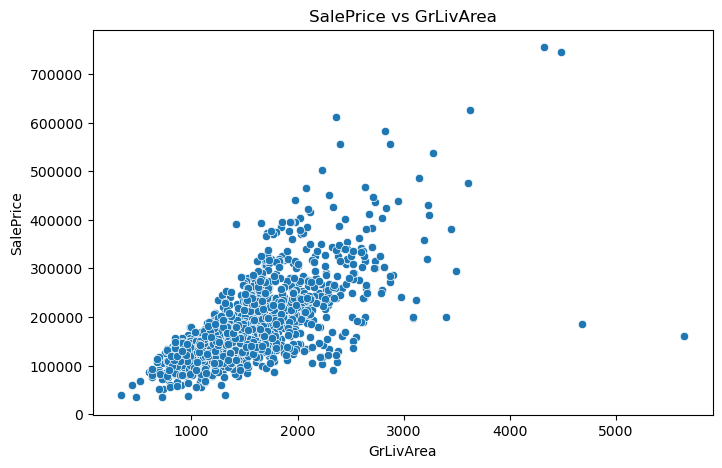

In [283]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["GrLivArea"],
    y=df["SalePrice"]
)

plt.title("SalePrice vs GrLivArea")
plt.show()

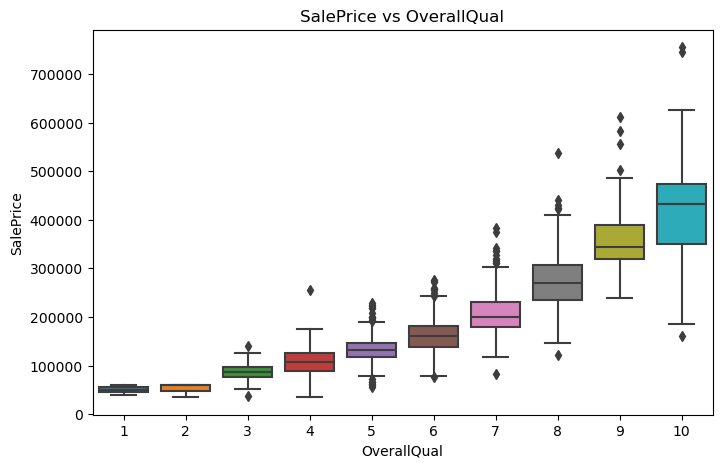

In [284]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["OverallQual"],
    y=df["SalePrice"]
)

plt.title("SalePrice vs OverallQual")
plt.show()


couple of outliers can be seen in the dataset which can auto corrected by the random forest regressor

# base line regression model 

In [285]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

In [286]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1168, 80)
X_test : (292, 80)
y_train: (1168,)
y_test : (292,)


In [287]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 37
Categorical Columns: 43


filling the missing values with the median of the data 

In [288]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

X[num_cols] = num_imputer.fit_transform(X[num_cols])

In [289]:
X[num_cols].isnull().sum().sum()

0

filling the Nan values with the most occured term in the column 

In [290]:
cat_imputer = SimpleImputer(strategy='most_frequent')

X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [291]:
X.isnull().sum().sum()

0

encoding the training data 


In [292]:
X = pd.get_dummies(X, drop_first=True)

In [293]:
print(X.shape)

(1460, 245)


In [294]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 245)
(292, 245)


Training the base line model 

In [295]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [296]:
predictions = model.predict(X_test)

print(predictions[:5])

[141543.75 320320.99 117811.5  153785.2  317890.42]


Evaluating the base line model 

In [297]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2 = r2_score(y_test, predictions)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

print("R² Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

R² Score : 0.8952010298882774
MAE      : 17481.776643835616
MSE      : 803842286.9341656
RMSE     : 28352.112565630196


# Regression Model with Feature Engineering

In [298]:
missing = df.isnull().sum()
missing[missing > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [299]:
df_fe2 = df.copy()
none_cols = [
    'PoolQC',
    'Alley',
    'FireplaceQu',
    'Fence',
    'MiscFeature',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2'
]

for col in none_cols:
    df_fe2[col] = df_fe2[col].fillna("None")

Removing the outliers

In [300]:
df_fe2 = df_fe2.drop(
    df_fe2[
        (df_fe2['GrLivArea'] > 4000) &
        (df_fe2['SalePrice'] < 300000)
    ].index
)

print(df_fe2.shape)

(1458, 81)


In [301]:
df_fe2["HouseAge"] = df_fe2["YrSold"] - df_fe2["YearBuilt"]

df_fe2["TotalArea"] = (
    df_fe2["TotalBsmtSF"] +
    df_fe2["1stFlrSF"] +
    df_fe2["2ndFlrSF"]
)

df_fe2["TotalBath"] = (
    df_fe2["FullBath"] +
    0.5 * df_fe2["HalfBath"]
)

In [302]:
df_fe2[none_cols].isnull().sum()

PoolQC          0
Alley           0
FireplaceQu     0
Fence           0
MiscFeature     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

In [303]:
df_fe2.isnull().sum().sum()

1221

In [304]:
missing = df_fe2.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

MasVnrType     872
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
Electrical       1
dtype: int64

In [305]:
df_fe2["MasVnrType"] = df_fe2["MasVnrType"].fillna("None")

df_fe2["LotFrontage"] = df_fe2["LotFrontage"].fillna(
    df_fe2["LotFrontage"].median()
)

df_fe2["GarageYrBlt"] = df_fe2["GarageYrBlt"].fillna(
    df_fe2["GarageYrBlt"].median()
)

df_fe2["MasVnrArea"] = df_fe2["MasVnrArea"].fillna(
    df_fe2["MasVnrArea"].median()
)

df_fe2["Electrical"] = df_fe2["Electrical"].fillna(
    df_fe2["Electrical"].mode()[0]
)

In [306]:
df_fe2.isnull().sum().sum()

0

dropping the features which are not useful for modeling

In [307]:
cols_to_drop = [col for col in ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature'] if col in df_fe2.columns]
df_fe2.drop(columns=cols_to_drop, inplace=True)

In [308]:
import numpy as np

y_fe2 = np.log1p(df_fe2["SalePrice"])

X_fe2 = df_fe2.drop("SalePrice", axis=1)

print(X_fe2.shape)

(1458, 78)


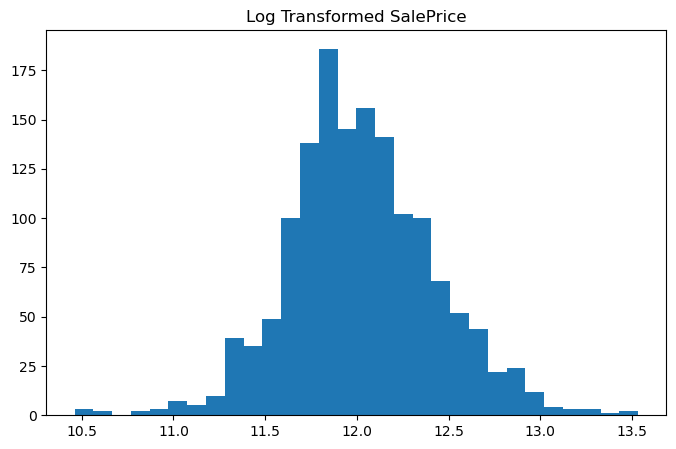

In [309]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y_fe2, bins=30)

plt.title("Log Transformed SalePrice")
plt.show()

one hot encoding the categorical columns in the data 

In [310]:
X_fe2 = pd.get_dummies(X_fe2, drop_first=True)

print(X_fe2.shape)

(1458, 248)


In [311]:
from sklearn.model_selection import train_test_split

X_train_fe2, X_test_fe2, y_train_fe2, y_test_fe2 = train_test_split(
    X_fe2,
    y_fe2,
    test_size=0.2,
    random_state=42
)


In [312]:
from sklearn.ensemble import RandomForestRegressor

model_fe2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_fe2.fit(X_train_fe2, y_train_fe2)

RandomForestRegressor(random_state=42)

In [313]:
pred_fe2 = model_fe2.predict(X_test_fe2)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2_fe2 = r2_score(y_test_fe2, pred_fe2)
mae_fe2 = mean_absolute_error(y_test_fe2, pred_fe2)
mse_fe2 = mean_squared_error(y_test_fe2, pred_fe2)
rmse_fe2 = np.sqrt(mse_fe2)

print("R² Score :", r2_fe2)
print("MAE      :", mae_fe2)
print("MSE      :", mse_fe2)
print("RMSE     :", rmse_fe2)

R² Score : 0.876574222969501
MAE      : 0.09818249662442598
MSE      : 0.020806656360163375
RMSE     : 0.14424512594941769


# comparing the Random forest model with the linear regression model 

In [314]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_fe2, y_train_fe2)
pred_lr = lr.predict(X_test_fe2)


In [315]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2_lr = r2_score(y_test_fe2, pred_lr)

mae_lr = mean_absolute_error(y_test_fe2, pred_lr)

mse_lr = mean_squared_error(y_test_fe2, pred_lr)

rmse_lr = np.sqrt(mse_lr)

print("R² Score :", r2_lr)
print("MAE      :", mae_lr)
print("MSE      :", mse_lr)
print("RMSE     :", rmse_lr)

R² Score : 0.8909227198160328
MAE      : 0.09210302972384524
MSE      : 0.018387840369263015
RMSE     : 0.13560177126152526
